In [2]:
%run plots.ipynb

check evaluation_6_5F in all weeks and single image training

evaluation_Mask evaluation

In [17]:
experiment_folder = "experimentsLongitudinal/" #preTreatment"w2 two_weeks#"wei_experiments/experimentsLongitudinal/two_weeks/"
weeks = "two_weeks/"
#name_file = "results_Fold1.xlsx"
model = "densenet"
endpoint = "DFS"

In [18]:
#path_to_evaluation_folder = "/scratch/hb-weeklyCT/"+experiment_folder+weeks+endpoint+"/evaluation_"+model+"_3F_new/"+name_file #evaluation_resnet_3F

In [19]:
#path_to_evaluation_folder = "/scratch/hb-weeklyCT/experimentsLongitudinal/"+experiment_folder+"/"+endpoint+"/evaluation/"+name_file

results_Fold1.xlsx


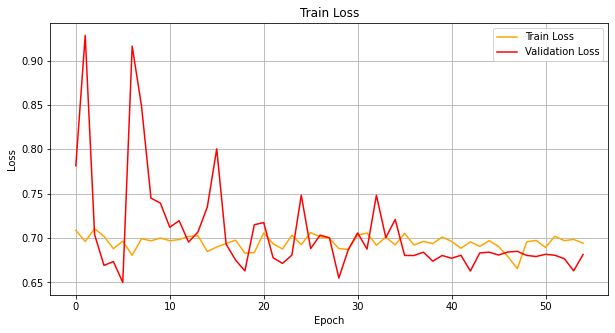

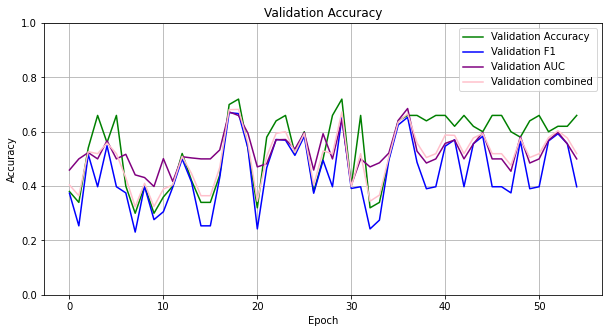

Best value saved for epoch: 17
Accuracy: 0.7
F1: 0.6703296703296704


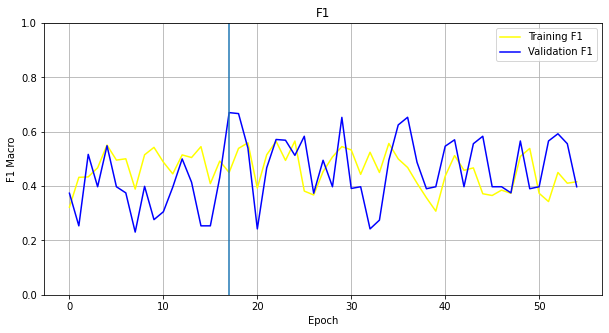

--------------------
results_Fold2.xlsx


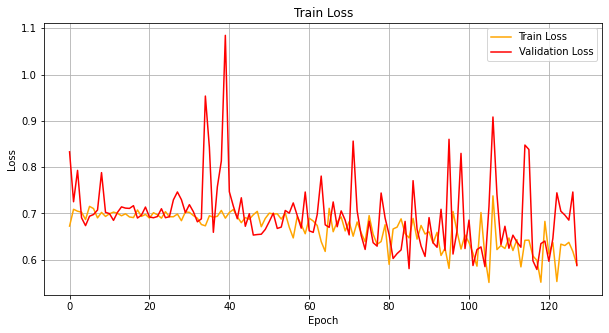

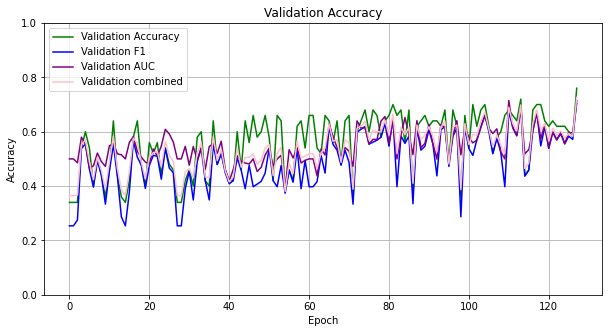

Best value saved for epoch: 127
Accuracy: 0.76
F1: 0.7142857142857142


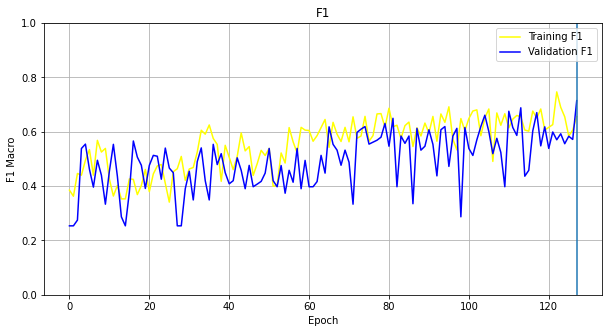

--------------------
results_Fold3.xlsx


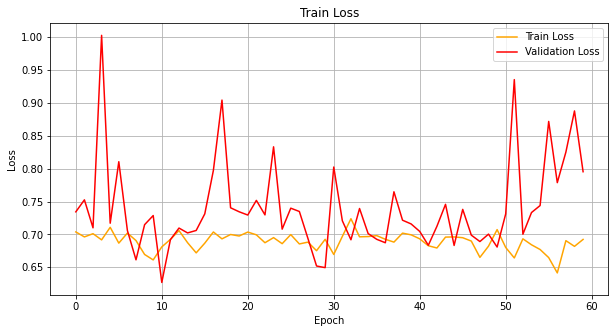

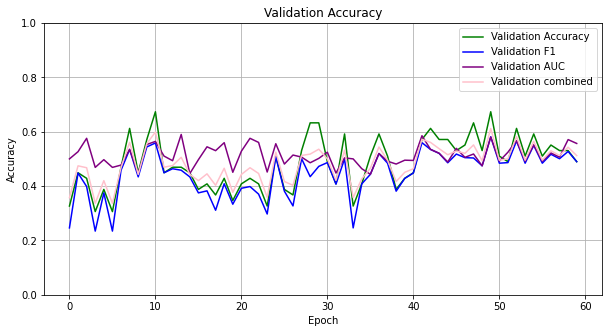

Best value saved for epoch: 49
Accuracy: 0.673469387755102
F1: 0.5811965811965812


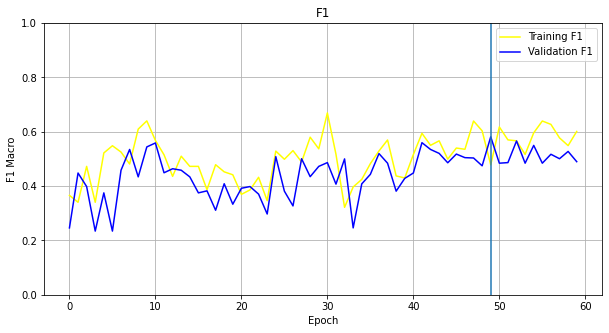

--------------------


In [20]:
for name_file in ["results_Fold1.xlsx","results_Fold2.xlsx","results_Fold3.xlsx"]:
    print(name_file)
    path_to_evaluation_folder = "/scratch/hb-weeklyCT/"+experiment_folder+weeks+endpoint+"/evaluation_"+model+"_3F_TCN_nopCT_long/"+name_file
    df = pd.read_excel(path_to_evaluation_folder)
    plot_two_loss(df)
    plot_metrics(df)
    plot_f1(df)
    print("--------------------")

In [21]:
#plot_one_loss(df, name='Train Loss', color="orange")

In [22]:
#plot_one_loss(df, name='Val Loss', color="red")

### Evaluation:

In [1035]:
experiment_folder = "experimentsLongitudinal/two_weeks/" #"wei_experiments/experimentsLongitudinal/two_weeks/"
name_file = "results_Fold3.xlsx"
endpoint = "DFS"

#evaluation_7Wlr_5F
path_to_evaluation_folder = "/scratch/hb-weeklyCT/"+experiment_folder+"/"+endpoint+"/evaluation_resnet_3F_new/"+name_file

In [1036]:
df = pd.read_excel(path_to_evaluation_folder)

In [92]:
np.max(df["Val Accuracy"])

0.5306122448979592

In [93]:
np.max(df["Val F1"])

0.5050505050505051

Cross Validation Results:

In [3]:
f1s = list()
auc = list()
accurac = list()

for i in range(1,4): 
    experiment_folder = "experimentsLongitudinal/two_weeks/" #"wei_experiments/experimentsLongitudinal/two_weeks/" preTreatment
    name_file = "results_Fold"+str(i)+".xlsx"
    endpoint = "DFS"

    path_to_evaluation_folder = "/scratch/hb-weeklyCT/"+experiment_folder+"/"+endpoint+"/evaluation_densenet_3F_nopCT_long/"+name_file
    
    df = pd.read_excel(path_to_evaluation_folder)
    
    df = df[15:]
    
    _index = df['Val F1'].idxmax() #df['Val Loss'].idxmin() #
    
    print("Best value saved for epoch: " + str(_index))
    f1s.append(df.loc[_index, 'Val F1'])
    accurac.append(df.loc[_index, 'Val Accuracy'])
    auc.append(df.loc[_index, 'Val AUC'])
    
    print("Fold " + str(i))
    print("Accuracy: " + str(df.loc[_index, 'Val Accuracy']))
    print("F1: " + str((df.loc[_index, 'Val F1'])))
    print("AUC: " + str(df.loc[_index, 'Val AUC']))
    print("----")
    
print("Average Accuracy score: {:.2f} ± {:.2f}".format(np.mean(accurac), np.std(accurac)))
print("Average F1 score: {:.2f} ± {:.2f}".format(np.mean(f1s), np.std(f1s)))
print("Average AUC score: {:.2f} ± {:.2f}".format(np.mean(auc), np.std(auc)))

Best value saved for epoch: 137
Fold 1
Accuracy: 0.8
F1: 0.7702205882352942
AUC: 0.7629233511586452
----
Best value saved for epoch: 36
Fold 2
Accuracy: 0.64
F1: 0.6394230769230769
AUC: 0.6987522281639929
----
Best value saved for epoch: 39
Fold 3
Accuracy: 0.5918367346938775
F1: 0.5833333333333334
AUC: 0.6164772727272727
----
Average Accuracy score: 0.68 ± 0.09
Average F1 score: 0.66 ± 0.08
Average AUC score: 0.69 ± 0.06


### Overall Validation Scores:

In [100]:
experiment_folder = "w4" #"wei_experiments/experimentsLongitudinal/two_weeks/"

endpoint = "DFS"

experiment_type = "single"

In [101]:
#single time point or multi time point with self attention
experiment_names = {
                    "single" : ["evaluation_densenet_3F_new","evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                    "multi_selfAtt" : ["evaluation_densenet_3F_new","evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                    "multi_TCN" : ["evaluation_densenet_3F_TCN","evaluation_resnet_3F_TCN","evaluation_seresnet_3F_TCN"],
                    "multi_selfAtt_nopCT" : ["evaluation_densenet_3F_nopCT","evaluation_resnet_3F_nopCT","evaluation_seresnet_3F_nopCT"],
                    "multi_TCN_nopCT" : ["evaluation_densenet_3F_TCN_nopCT","evaluation_resnet_3F_TCN_nopCT","evaluation_seresnet_3F_TCN_nopCT"]
                    }

In [102]:
f1s = list()
auc = list()
accurac = list()

experiment_name = experiment_names[experiment_type]

for folder in experiment_name:
    for i in range(1,4): 
        name_file = "results_Fold"+str(i)+".xlsx"

        path_to_evaluation_folder = "/scratch/hb-weeklyCT/experimentsLongitudinal/"+experiment_folder+"/"+endpoint+"/"+folder+"/"+name_file

        df = pd.read_excel(path_to_evaluation_folder)

        df = df[15:]

        _index = df['Val F1'].idxmax() #df['Val Loss'].idxmin() #

        #print("Best value saved for epoch: " + str(_index))
        f1s.append(df.loc[_index, 'Val F1'])
        accurac.append(df.loc[_index, 'Val Accuracy'])
        auc.append(df.loc[_index, 'Val AUC'])

        #print("Fold " + str(i))
        #print("Accuracy: " + str(df.loc[_index, 'Val Accuracy']))
        #print("F1: " + str((df.loc[_index, 'Val F1'])))
        #print("AUC: " + str(df.loc[_index, 'Val AUC']))
        #print("----")
    
print("Average Accuracy score: {:.2f} ± {:.2f} [{:.2f},{:.2f}]".format(np.mean(accurac), np.std(accurac),np.min(accurac), np.max(accurac)))
print("Average F1 score: {:.2f} ± {:.2f} [{:.2f},{:.2f}]".format(np.mean(f1s), np.std(f1s),np.min(f1s), np.max(f1s)))
print("Average AUC score: {:.2f} ± {:.2f} [{:.2f},{:.2f}]".format(np.mean(auc), np.std(auc),np.min(auc), np.max(auc)))

Average Accuracy score: 0.73 ± 0.05 [0.66,0.80]
Average F1 score: 0.66 ± 0.06 [0.57,0.77]
Average AUC score: 0.65 ± 0.06 [0.57,0.77]
